In [12]:
import pylab as plt
import numpy as np
from matplotlib import gridspec
import matplotlib.gridspec as gridspec

In [13]:
# Read data

nonrepfreq=np.loadtxt('60217_freq.txt')
rep1freq=np.loadtxt('60070_freq.txt')
rep2freq=np.loadtxt('60215_freq.txt')
freqs=[i*1000 for i in nonrepfreq]#all same
print(nonrepfreq[0])
nonrepfreq=nonrepfreq[:380]#this is the frequency we are going to use 
freq=[i*1000 for i in nonrepfreq]

1.312000036239624


In [14]:
nonrepfreq[167],nonrepfreq[168]

(np.float64(1.4950000047683716), np.float64(1.6959999799728394))

In [15]:
# Nonrepeater

nonrep=np.load('60217_30int.npy')
# nonrepdata=nonrep.T[:380,:]
averaged_data = (nonrep[::2] + nonrep[1::2]) / 2
nonrepdata = averaged_data.T[:380]


#missing frequencies append
missing_freqs = np.arange(1496, 1696, 1)
missing_data = np.zeros((len(missing_freqs), nonrepdata.shape[1]))  

# Stack missing and existing data
all_data = np.vstack((missing_data, nonrepdata))
all_frequencies = np.concatenate((missing_freqs, freq))  # Ensure consistent order

# Sort by frequency
sorted_indices = np.argsort(all_frequencies)
padded_frequencies = all_frequencies[sorted_indices]
nonrep_final = all_data[sorted_indices]  # Corrected variable name




In [16]:
#Repeater B2
rep2=np.load('60215_30int.npy')
rep2data = rep2.T[:380]


#missing frequencies append
missing_freqs = np.arange(1496, 1696, 1)
missing_data = np.zeros((len(missing_freqs), rep2data.shape[1]))  

# Stack missing and existing data
all_data = np.vstack((missing_data, rep2data))
all_frequencies = np.concatenate((missing_freqs, freq))  # Ensure consistent order

# Sort by frequency
sorted_indices = np.argsort(all_frequencies)
padded_frequencies = all_frequencies[sorted_indices]
rep2_final = all_data[sorted_indices]  # Corrected

# plt.imshow(rep2.T,aspect='auto',interpolation=None)

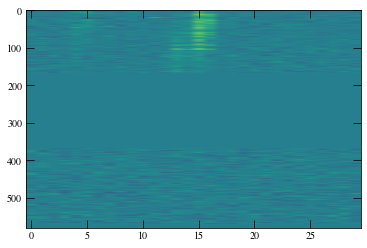

In [17]:
plt.imshow(rep2_final,aspect='auto',interpolation=None)

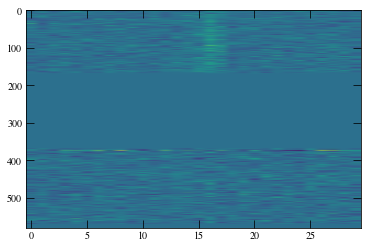

In [18]:
#Repeater B1
rep1=np.load('60070_30int.npy')
rep1data = rep1.T[:380]


#missing frequencies append
missing_freqs = np.arange(1496, 1696, 1)
missing_data = np.zeros((len(missing_freqs), rep1data.shape[1]))  

# Stack missing and existing data
all_data = np.vstack((missing_data, rep1data))
all_frequencies = np.concatenate((missing_freqs, freq))  # Ensure consistent order

# Sort by frequency
sorted_indices = np.argsort(all_frequencies)
padded_frequencies = all_frequencies[sorted_indices]
rep1_final = all_data[sorted_indices]  # Corrected
plt.imshow(rep1_final,aspect='auto',interpolation=None)

In [19]:
tsamp=[0.02,0.01,0.01] # FROM DATA HEADER
freq=[padded_frequencies,padded_frequencies,padded_frequencies]
names=['FRB20230930A', 'FRB20230506C B1','FRB20230506C B2']
data=[nonrep_final,rep1_final,rep2_final]

In [20]:
plt.rcParams['legend.frameon'  ] = False
plt.rcParams['font.family'     ] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction' ] = 'in'
plt.rcParams['ytick.direction' ] = 'in'
plt.rcParams['xtick.top'       ] = True
plt.rcParams['ytick.right'     ] = True
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['xtick.major.width'] = 0.75
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.75
plt.rcParams['ytick.minor.width'] = 0.5

In [21]:
def make_plot_gs(gs,data, freqs,tsamp,names,plt_idx):
    gss = gs.subgridspec(2, 1, height_ratios=[1, 3], # width_ratios=[4, 1], 
                         wspace=0, hspace=0)
    ax00 = plt.subplot(gss[0, 0])
    ax00.plot(np.average(data,axis=0))

    ax10 = plt.subplot(gss[1, 0], sharex = ax00)
    im=ax10.imshow(data, aspect='auto',interpolation='none')
    ax00.text(0.25,0.85,names,fontsize=12,ha="center", va="center", wrap=True, transform=ax00.transAxes)
    ax10.invert_yaxis()
    a = np.linspace(freqs[0],freqs[-1],3,dtype=int)
    fbin=freqs[0]-freqs[1]
    a1=np.round(a,decimals=-1)
    a2=np.round([a1[0],int(a1[1]+(10*fbin)),int(a1[2]+(40*fbin))],decimals=-1)
    tlen = data.shape[1]
    ts = np.linspace(-tlen // 2, tlen // 2, 6)*tsamp*1000
    ts_int=np.round(ts,decimals=-1)

    ax10.set_xticks([1,tlen//2,tlen-1], [int(np.min(ts_int)),0,int(np.max(ts_int))])
    a2=np.round([a1[0],int(a1[1]+(10*fbin)),int(a1[2]+(40*fbin))],decimals=-1)
    ax10.set_yticks([0,data.shape[0]//2-10,data.shape[0]-10],a2)
    ax00.get_xaxis().set_visible(False)
    ax00.tick_params(axis='both', which='major', labelsize=14)
    ax10.tick_params(axis='both', which='major', labelsize=14)
    ax10.tick_params(axis='y',rotation=90)
    
    i, j = plt_idx
    if j == 0:
        ax10.set_ylabel('Freq (MHz)',fontsize=16)
        ax00.set_ylabel('Arb. flux',fontsize=12)
    if i==0:
        ax10.set_xlabel('Time (ms)',fontsize=16)


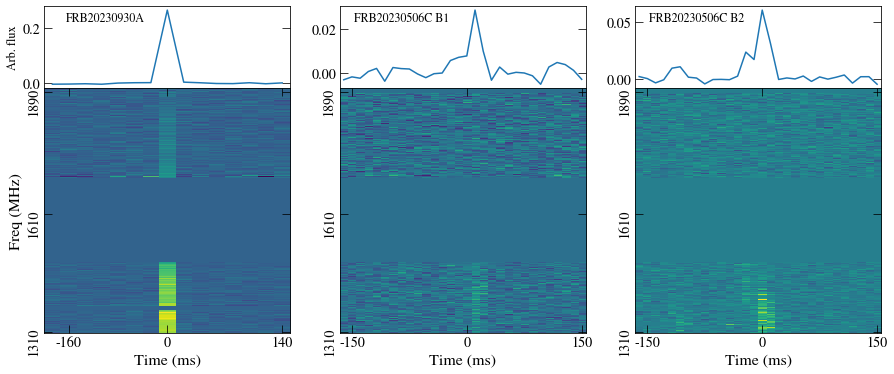

In [22]:
fig = plt.figure()
fig.set_size_inches(15, 6)
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], height_ratios=[1])
nrows, ncols = 1, 3
for i in range(nrows):
    for j in range(ncols):
        gss = gs[i, j]
        idx = i*3 + j

        make_plot_gs(gss,data[idx], freq[idx],tsamp[idx],names[idx],plt_idx = (i, j))
        
plt.savefig('M31_spectrogram.png',dpi=360,bbox_inches='tight')#

In [ ]:
plt.style.use('dark_background')

In [ ]:
fig = plt.figure()
fig.set_size_inches(15, 6)
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], height_ratios=[1])
nrows, ncols = 1, 3
for i in range(nrows):
    for j in range(ncols):
        gss = gs[i, j]
        idx = i*3 + j
        
        #bname = freq[idx]
        #print(bname)

        make_plot_gs(gss,data[idx], freq[idx],tsamp[idx],names[idx],plt_idx = (i, j))
        
# plt.savefig('M31_spectrogram.pdf',dpi=720,bbox_inches='tight')
plt.savefig('M31_spectrogram_black.png',dpi=200,bbox_inches='tight')